# Part a

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set a random seed for reproducibility
np.random.seed(42)

# Generate 100 random points in a 1x1 square
N_points = 100
x_coords = np.random.uniform(0, 1, N_points)
y_coords = np.random.uniform(0, 1, N_points)

# Check which points fall inside the quarter circle (x^2 + y^2 <= 1)
inside_circle_mask = (x_coords**2 + y_coords**2) <= 1

# Count the successes
h_hits = np.sum(inside_circle_mask)

print(f"Total points generated (N): {N_points}")
print(f"Points inside the quarter circle (h): {h_hits}")

Total points generated (N): 100
Points inside the quarter circle (h): 80


80 points fall in the quarter circle of radius 1 in the 1 × 1 square with random 100 points.

# Part b

In [3]:
# Prior parameters (Flat Prior)
alpha_prior = 1
beta_prior = 1

# Calculate Posterior Mean for p (probability of single point falling inside the quarter-circle)
posterior_mean_p = (alpha_prior + h_hits) / (alpha_prior + beta_prior + N_points) # Expected value (mean) of posterior distribution

# Calculate Pi (probability = area of quarter circle/area of square = Pi/4)
pi_estimate = 4 * posterior_mean_p

print(f"Posterior Mean for p: {posterior_mean_p:.4f}")
print(f"Bayesian Estimate for Pi: {pi_estimate:.4f}")

Posterior Mean for p: 0.7941
Bayesian Estimate for Pi: 3.1765


Thus the probability of a point falling inside of the cicle (expected value of posterior distribution) is 0.79.


The estimate for π is 3.18.

# Part c

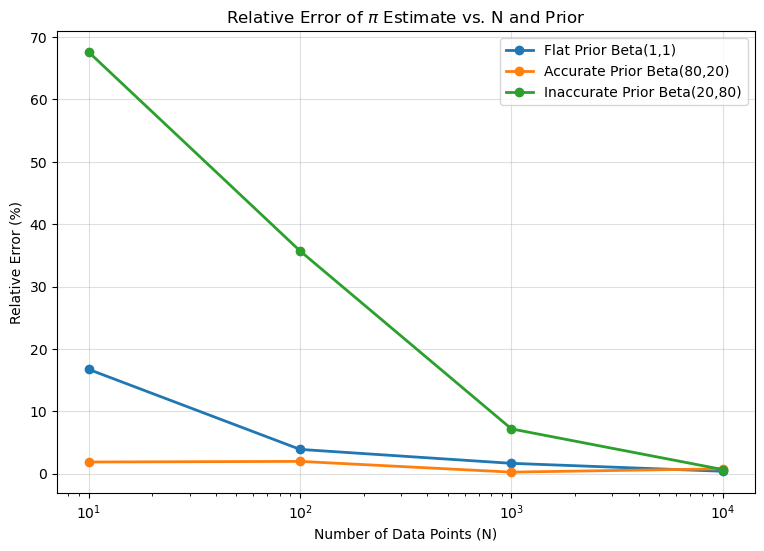

In [4]:
# Define the parameters to test
N_values = [10, 100, 1000, 10000]

# True p is pi/4 approx 0.785
priors = [
    (1, 1, 'Flat Prior Beta(1,1)'),
    (80, 20, 'Accurate Prior Beta(80,20)'), # True p is pi/4 approx 0.785
    (20, 80, 'Inaccurate Prior Beta(20,80)') 
]

true_pi = np.pi

plt.figure(figsize=(9, 6))

# Run the simulation
for alpha_prior, beta_prior, label in priors:
    errors = []
    
    for N in N_values:
        x = np.random.uniform(0, 1, N)
        y = np.random.uniform(0, 1, N)
        h_hits = np.sum((x**2 + y**2) <= 1)
      
        posterior_mean = (alpha_prior + h_hits) / (alpha_prior + beta_prior + N)
        pi_estimate = 4 * posterior_mean
        
        # Calculate Relative Error
        rel_error = (abs(pi_estimate - true_pi) / true_pi) * 100
        errors.append(rel_error)
        
    # Plot the error curve for this prior
    plt.plot(N_values, errors, marker='o', linewidth=2, label=label)

plt.xscale('log')
plt.xlabel('Number of Data Points (N)')
plt.ylabel('Relative Error (%)')
plt.title('Relative Error of $\pi$ Estimate vs. N and Prior')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

We used three prior: An accurate prior of Beta(80, 20), a flat prior of Beta(1,1), and an inaccurate prior of Beta(20,80). As we saw in the part 2, the prior has a massive impact for small number of data points, N but its influence vanishes for large N. For small N, the relative error is very big for for inaccurate prior compared to accurate prior. For large N, the relative error very less (ϵ < 1% for N = 10000) irrespective of the prior. The error decreases as N increases.